# 2. Price value of electricity

## a) Baseload price — full year and monthly (2019)

In [1]:
import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

os.makedirs("figures", exist_ok=True)

In [2]:
df = pl.read_csv(
    "data/data_1.csv",
    try_parse_dates=True,
)
df

datetime_cet,price,solar,hydro,wind,nuclear,lignite,X
datetime[μs],f64,f64,f64,f64,f64,f64,i64
2019-01-01 00:00:00,51.0,0.0,69.0,0.0,694.0,246.0,1144
2019-01-01 01:00:00,46.27,0.0,134.0,0.0,695.0,262.0,1087
2019-01-01 02:00:00,39.78,0.0,68.0,0.0,695.0,250.0,1016
2019-01-01 03:00:00,27.87,0.0,67.0,0.0,694.0,250.0,952
2019-01-01 04:00:00,-0.36,0.0,67.0,0.0,694.0,218.0,919
…,…,…,…,…,…,…,…
2019-12-31 19:00:00,46.0,0.0,788.0,1.0,697.0,242.0,1552
2019-12-31 20:00:00,42.2,0.0,791.0,1.0,697.0,244.0,1448
2019-12-31 21:00:00,39.74,0.0,725.0,1.0,697.0,244.0,1299


In [3]:
baseload_annual = df["price"].mean()
print(f"Baseload value 2019: {baseload_annual:.2f} €/MWh")

Baseload value 2019: 48.75 €/MWh


In [ ]:
monthly_baseload = (
    df
    .with_columns(pl.col("datetime_cet").dt.month().alias("month"))
    .group_by("month")
    .agg(pl.col("price").mean().alias("baseload_€MWh"))
    .sort("month")
)

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_baseload = monthly_baseload.with_columns(
    pl.col("month").map_elements(lambda m: month_names[m-1], return_dtype=pl.String).alias("month_name")
)

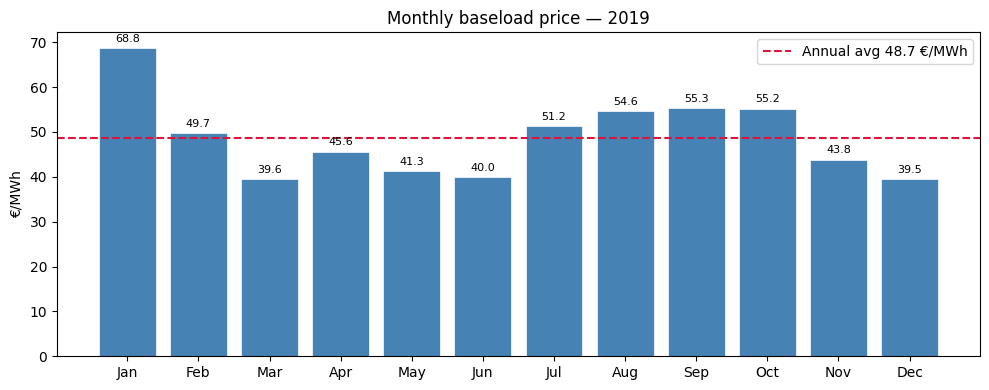

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
months = monthly_baseload["month_name"].to_list()
values = monthly_baseload["baseload_€MWh"].to_list()
bars = ax.bar(months, values, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axhline(baseload_annual, color="crimson", linewidth=1.5, linestyle="--", label=f"Annual avg {baseload_annual:.1f} €/MWh")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.set_ylabel("€/MWh")
ax.set_title("Monthly baseload price — 2019")
ax.legend()
plt.tight_layout()
plt.savefig("figures/task_2a_baseload_monthly.png", dpi=150)
plt.show()

## b) Monthly peakload prices (2019)

Peakload = hours 08:00–20:00, Monday–Friday only (12 h/day × 5 days = 60 h/week).

In [6]:
# Peak hours: start hour in [8, 19] and weekday Mon–Fri (ISO weekday 1–5)
df_peak = df.with_columns([
    pl.col("datetime_cet").dt.month().alias("month"),
    pl.col("datetime_cet").dt.hour().alias("hour"),
    pl.col("datetime_cet").dt.weekday().alias("weekday"),  # 1=Mon … 7=Sun
])

peak_mask = (
    (pl.col("hour") >= 8) & (pl.col("hour") <= 19) &
    (pl.col("weekday") <= 5)  # Mon–Fri
)

monthly_peakload = (
    df_peak
    .filter(peak_mask)
    .group_by("month")
    .agg(pl.col("price").mean().alias("peakload_€MWh"))
    .sort("month")
    .with_columns(
        pl.col("month").map_elements(lambda m: month_names[m-1], return_dtype=pl.String).alias("month_name")
    )
)
#print(monthly_peakload.select(["month_name", "peakload_€MWh"]))

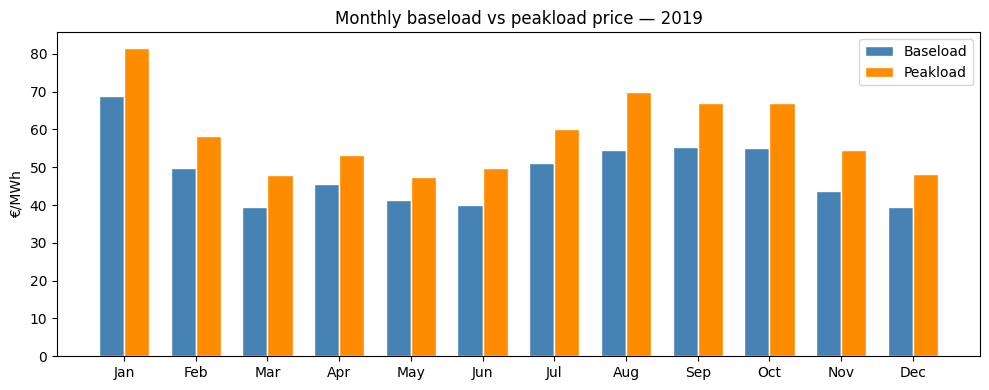

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
months_pl = monthly_peakload["month_name"].to_list()
peak_values = monthly_peakload["peakload_€MWh"].to_list()
base_values = monthly_baseload["baseload_€MWh"].to_list()

x = np.arange(len(months_pl))
w = 0.35
ax.bar(x - w/2, base_values, w, label="Baseload", color="steelblue", edgecolor="white")
ax.bar(x + w/2, peak_values, w, label="Peakload", color="darkorange", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(months_pl)
ax.set_ylabel("€/MWh")
ax.set_title("Monthly baseload vs peakload price — 2019")
ax.legend()
plt.tight_layout()
plt.savefig("figures/task_2b_peakload_monthly.png", dpi=150)
plt.show()

## c) Total production per source and total consumption of Consumer X (2019)

Production columns are in MWh. Consumer X is in kWh — divide by 1000 to convert to MWh.

In [8]:
plant_cols = ["solar", "hydro", "wind", "nuclear", "lignite"]

totals = {col: df[col].sum() for col in plant_cols}
totals["Consumer X"] = df["X"].sum() / 1000  # kWh → MWh

print(f"{'Source':<15} {'Total [MWh]':>15}")
print("-" * 32)
for src, val in totals.items():
    print(f"{src:<15} {val:>15,.0f}")

Source              Total [MWh]
--------------------------------
solar                   245,268
hydro                 4,309,297
wind                      4,636
nuclear               5,499,420
lignite               3,997,051
Consumer X                8,843


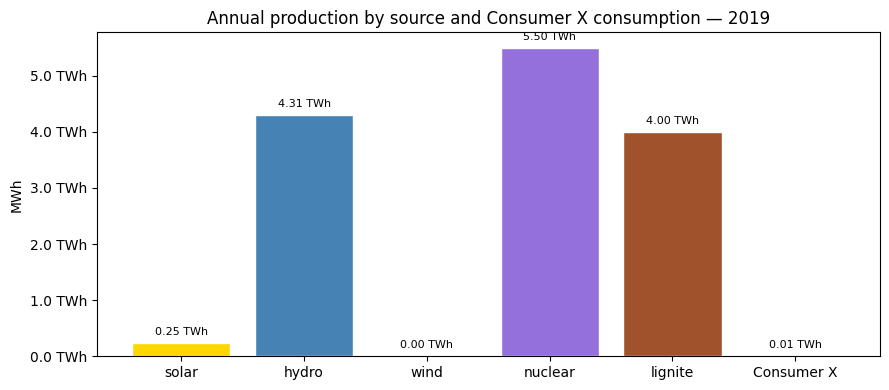

In [9]:
labels = list(totals.keys())
vals   = list(totals.values())
colors = ["gold", "steelblue", "mediumseagreen", "mediumpurple", "sienna", "tomato"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, vals, color=colors, edgecolor="white")
ax.bar_label(bars, fmt=lambda v: f"{v/1e6:.2f} TWh", padding=4, fontsize=8)
ax.set_ylabel("MWh")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f} TWh"))
ax.set_title("Annual production by source and Consumer X consumption — 2019")
plt.tight_layout()
plt.savefig("figures/task_2c_production_totals.png", dpi=150)
plt.show()

## d) Average value of power per source and Consumer X

The *value* of electricity produced (or consumed) is the volume-weighted average price — i.e. the average spot price weighted by the hourly output (or consumption). This tells you what price a plant actually *captured* on average, not just what the market averaged.

In [10]:
prices = df["price"].to_numpy()

def weighted_avg_price(production: np.ndarray) -> float:
    """Volume-weighted average price (ignores missing/null hours)."""
    total = np.nansum(production)
    if total == 0:
        return float("nan")
    return np.nansum(prices * production) / total

values = {}
for col in plant_cols:
    values[col] = weighted_avg_price(df[col].to_numpy())

# Consumer X in kWh — units cancel in the ratio, so no conversion needed
values["Consumer X"] = weighted_avg_price(df["X"].to_numpy())

print(f"{'Source':<15} {'Avg value [€/MWh]':>20}")
print("-" * 37)
for src, val in values.items():
    print(f"{src:<15} {val:>20.2f}")

print(f"\nAnnual baseload reference:  {baseload_annual:.2f} €/MWh")

Source             Avg value [€/MWh]
-------------------------------------
solar                          50.89
hydro                          49.14
wind                           49.68
nuclear                        48.15
lignite                        51.79
Consumer X                     50.91

Annual baseload reference:  48.75 €/MWh


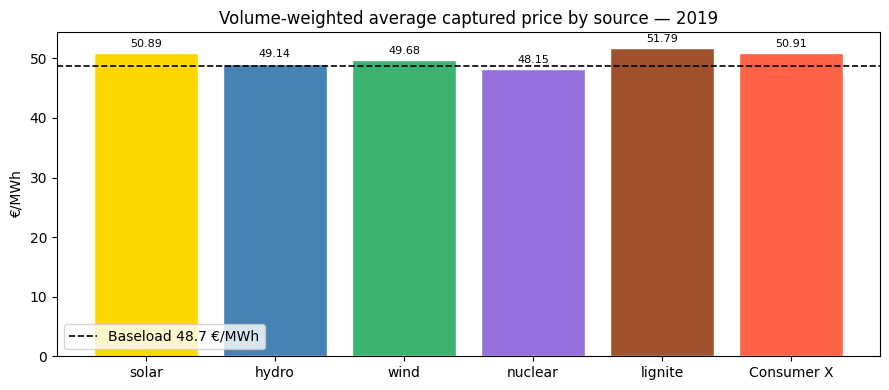

In [11]:
src_labels = list(values.keys())
src_vals   = list(values.values())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(src_labels, src_vals, color=colors, edgecolor="white")
ax.axhline(baseload_annual, color="black", linewidth=1.2, linestyle="--",
           label=f"Baseload {baseload_annual:.1f} €/MWh")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
ax.set_ylabel("€/MWh")
ax.set_title("Volume-weighted average captured price by source — 2019")
ax.legend()
plt.tight_layout()
plt.savefig("figures/task_2d_value_by_source.png", dpi=150)
plt.show()